In [2]:
import pandas as pd
import numpy as np

In [3]:
#importing dataset
df = pd.read_csv('bnpl_dataset.csv').dropna()


In [4]:
df.head()

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time


In [6]:
df.shape

(50000, 9)

In [7]:
df.columns

Index(['Transaction_ID', 'Customer_Age', 'Gender', 'Annual_Income',
       'Credit_Score', 'Purchase_Category', 'BNPL_Provider', 'Purchase_Amount',
       'Repayment_Status'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Transaction_ID     50000 non-null  object
 1   Customer_Age       50000 non-null  int64 
 2   Gender             50000 non-null  object
 3   Annual_Income      50000 non-null  int64 
 4   Credit_Score       50000 non-null  int64 
 5   Purchase_Category  50000 non-null  object
 6   BNPL_Provider      50000 non-null  object
 7   Purchase_Amount    50000 non-null  int64 
 8   Repayment_Status   50000 non-null  object
dtypes: int64(4), object(5)
memory usage: 3.4+ MB


In [10]:
df.isnull().sum()

Transaction_ID       0
Customer_Age         0
Gender               0
Annual_Income        0
Credit_Score         0
Purchase_Category    0
BNPL_Provider        0
Purchase_Amount      0
Repayment_Status     0
dtype: int64

In [11]:
df.describe()

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,69980.860200,573.569300,563.221980
std,13.528733,28923.444012,158.853766,706.078491
min,18.000000,20000.000000,300.000000,20.000000
25%,29.000000,44915.500000,435.000000,124.000000
50%,41.000000,70071.500000,572.000000,229.000000
75%,53.000000,95262.250000,711.000000,785.000000
max,64.000000,119998.000000,849.000000,2999.000000


In [12]:
df.duplicated().sum()

0

In [17]:
#Convert repayment status into a binary risk flag
df['Default_flag'] = df['Repayment_Status'].apply(lambda x:1 if x == 'Defaulted' else 0)


In [20]:
#Credit Score Banding

def credit_band(score):
    if score < 580:
        return 'poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    else:
        return 'Excellent'

df['credit_score_band'] = df['Credit_Score'].apply(credit_band)


In [25]:
#Income Grouping
df['Income_group'] = pd.qcut(
    df['Annual_Income'],
    q=3,
    labels=['low income', 'mid income', 'high income']
)


In [28]:
#Purchase Amount Buckets
df['purchase_band'] = pd.qcut(
    df['Purchase_Amount'],
    q=4,
    labels=['low', 'medium', 'high', 'very high']
)


In [29]:
#Overall Default Rate
#Business Question
#What percentage of transactions end in default?

default_rate = df['Default_flag'].mean() * 100
print(f"overall default rate: {default_rate:.2f}%")


overall default rate: 8.76%


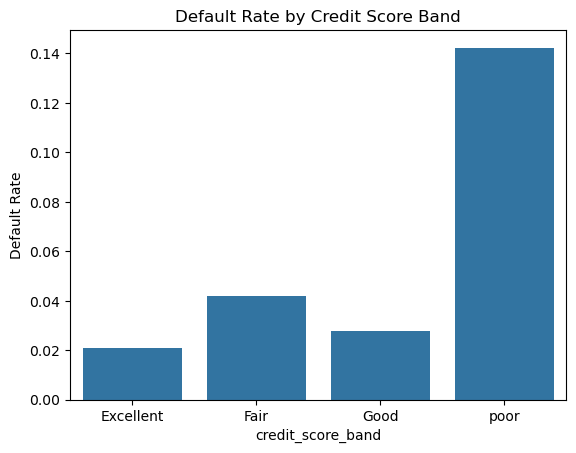

In [32]:
#Default Rate by Credit Score
# Business Question
#Do lower credit scores actually increase default risk?

import seaborn as sns
import matplotlib.pyplot as plt

credit_default = df.groupby('credit_score_band')['Default_flag'].mean().reset_index()

sns.barplot(data=credit_default, x='credit_score_band', y='Default_flag')
plt.title('Default Rate by Credit Score Band')
plt.ylabel('Default Rate')
plt.show()




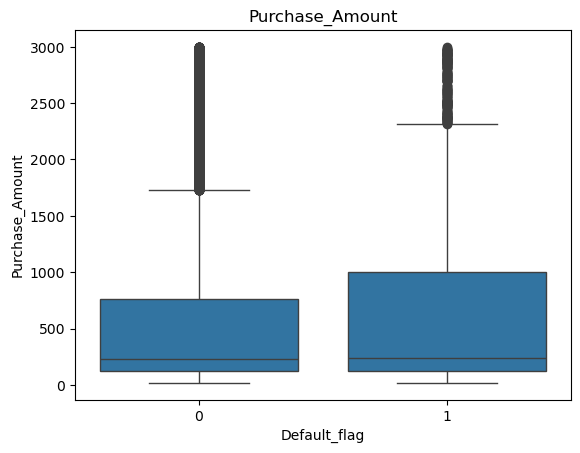

In [36]:
#Purchase Amount vs Default Risk
#Business Question
#Do larger purchases increase repayment failure?

sns.boxplot(data=df, x='Default_flag', y='Purchase_Amount')
plt.title('Purchase_Amount')
plt.show()



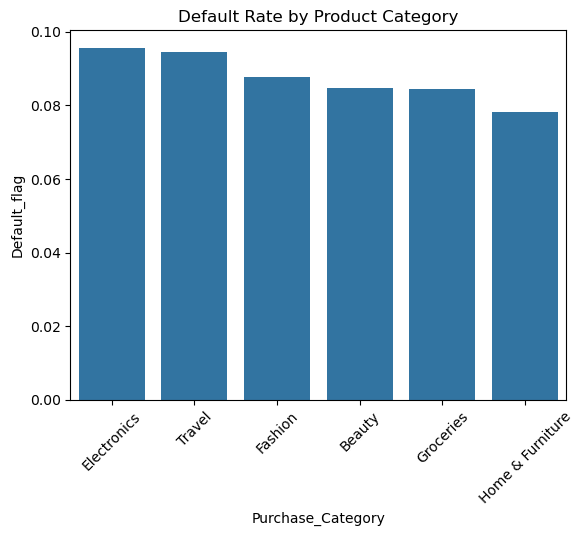

In [39]:
#Product Category Risk
#Business Question
#Which categories generate risky loans?

Category_risk = df.groupby('Purchase_Category')['Default_flag'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=Category_risk, x='Purchase_Category', y='Default_flag')
plt.xticks(rotation = 45)
plt.title('Default Rate by Product Category')
plt.show()



C:\Users\hp\AppData\Local\Temp\ipykernel_20360\2261954057.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby('Income_group')['Default_flag'].mean().reset_index()


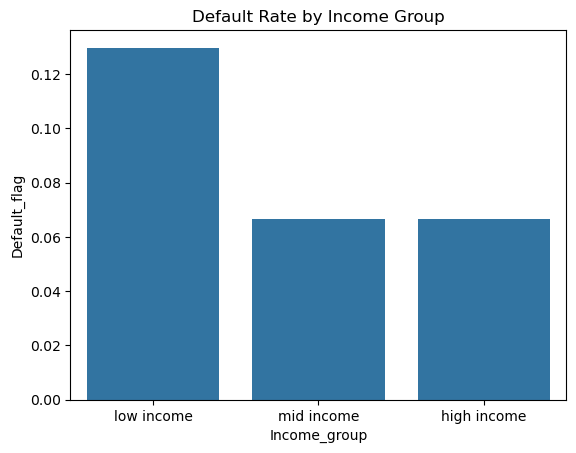

In [40]:
#Income Group vs Repayment Behavior
#Business Question
#Do high-income customers default less?

income_default = df.groupby('Income_group')['Default_flag'].mean().reset_index()

sns.barplot(data=income_default, x='Income_group', y='Default_flag')
plt.title('Default Rate by Income Group')
plt.show()



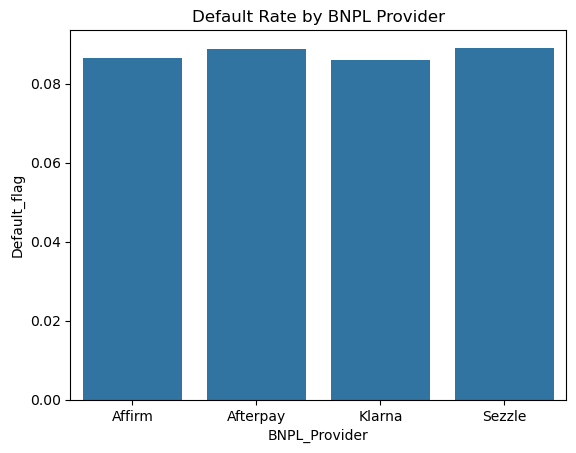

In [41]:
#BNPL Provider Risk Comparison
#Business Question
#Which provider has higher default exposure?

provider_risk = df.groupby('BNPL_Provider')['Default_flag'].mean().reset_index()

sns.barplot(data = provider_risk, x='BNPL_Provider', y='Default_flag')
plt.title('Default Rate by BNPL Provider')
plt.show()


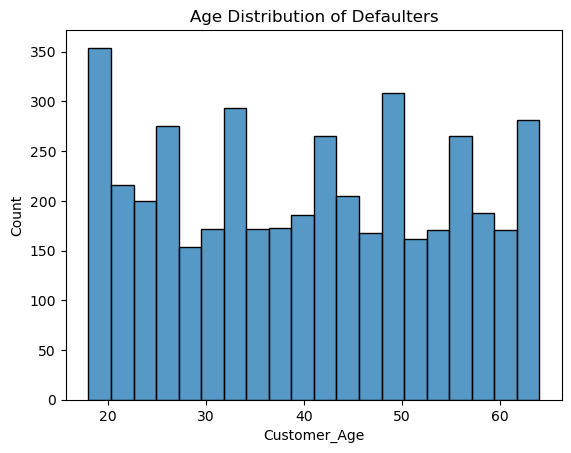

In [44]:
#Age Distribution of Defaulters
sns.histplot(data=df[df['Default_flag']==1], x='Customer_Age', bins=20)
plt.title("Age Distribution of Defaulters")
plt.show()


In [33]:
df

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status,Default_flag,credit_score_band,Income_group,purchase_band
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted,1,poor,low income,high
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time,0,poor,mid income,medium
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time,0,Fair,mid income,very high
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time,0,poor,high income,low
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time,0,poor,low income,very high
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5809f3a6-29c5-40f8-9452-f835ecc1f8f0,60,Male,78276,543,Groceries,Klarna,262,Paid On Time,0,poor,mid income,high
49996,88c98bc1-fd0c-43b8-b079-73826fdc64f2,46,Female,40989,828,Fashion,Sezzle,263,Paid On Time,0,Excellent,low income,high
49997,a50da40e-f7d0-49f3-b316-2ff8f09f117d,19,Female,64502,648,Travel,Affirm,1777,Paid On Time,0,Fair,mid income,very high
49998,e623faa5-4c8f-44f1-9a8c-4f8d8a23ffdf,43,Male,44026,481,Travel,Afterpay,1648,Paid On Time,0,poor,low income,very high
